## Surrogate Modeling on TACC Systems: Epidemic Simulation

Surrogate modeling is an engineering technique in which the evaluation of a complex system is replaced by the evaluation of a simpler one. One discovers the simpler system through data: with machine learning, one can identify coordinates in which the system dynamics evolve on a low-dimensional manifold. The resulting model is fast to evaluate, often 1 to 3 orders of magnitude faster than the original system, but with the limiation that predictions are only valid within a range determined by the training data. One can think of surrogate modeling as a sophsticated form of interpolation.

This tutorial walks through the process of surrogate modeling for a representative dynamical system: disease spread in the epidemic regime. Disease spread describes the process by which infectous pathogens are transmitted across a population in time and space. The dynamics of disease spread are multi-scale, chaotic, and highly uncertain, mandating a computational framework that can capture these various effects. 

To predict the spread of disease forward in time, computational scientist rely on idealized **compartment** models, in which individuals are partitioned into a finite number of compartments based on their current infection status. In this tutorial, we consider the SEIR compartment model, in which individuals are classified as susceptible (S), exposed (E), infected (I), or recovered (R). In its **deterministic** formulation, the SEIR compartment model evolves forward in time according to the following set of ODE's:

$$
\frac{dS}{dt} = -\frac{\beta I}{N} S
$$
$$
\frac{dE}{dt} = \frac{\beta I}{N} S - \sigma E
$$
$$
\frac{dI}{dt} = -\sigma E - \gamma I
$$
$$
\frac{dR}{dt} = \gamma I
$$

In the equation above $N$ is the total population, while [$\beta$, $\sigma$, and $\gamma$] are a set of numerical constants tuned to the regime of interest. The intial condition consists of a state vector, [$S_0$, $E_0$, $I_0$, $R_0$], where $E_0$ is seeded to some non-zero initial exposure. Note that these equations are often augmented to account for a variety of auxillarly effects, including migration between counties, age-dependent vulnerabilities, and vaccination rates. 

The SEIR equations happen to be a very good candidate for surrogate modeling. While the complete equations contain a spectrum of dynamics, decision-makers are often interested in a single regime, simulating a large number of similar scenarios related to a specific pathogen. Traditional numerical integration techniques are costly in this context, particularly when modeling populations with a large number of nodes/counties, and potentially redundant, given that each scenario is quite similar. 

For this tutorial, we build a surrogate model for the simulation of disease spread in Washington, DC. Our dataset consists of 40 separate similations, each corresponding to a different initial exposure and/or rate of infection, and tracks the four SEIR compartments over a period of 500 days. We partition the modeling process into the following key steps:

1. Data Loading and Normalization
2. Establishing a Network Architecture and Learning Objective
3. Model Training
4. Model Evaluation
5. Ablation Studies

Note that our dataset is simplified compared to a production simulation suite, but is still complex enough to illustrate several interesting aspects of the surrogate modeling pipeline. The goal of this tutorial is not to build a production model, but rather to give the reader an entry point into surrogate modeling on TACC systems. Let's get started!

In [5]:
# Import base python libraries
import functools
import os
import numpy as np
import pandas as pd
import torch
import glob
import time
import json
from matplotlib import pyplot as plt

# Import Pytorch for neural network training
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.utils.parametrizations as param

# Import sklearn libraries for convenient data segmentation
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Define device and 
print('Checking for GPU...')
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Checking for GPU...
Using device: mps


### Part 1: Data Loading and Normalization

We begin by loading a dataset of simulation outputs, which were completed prior to this tutorial. In total, we ran 40 simulations, configuring the simulations to mimic the conditions of disease spread in Washington DC. The district's low total population (compared to a large population like Texas) makes the modeling problem tractable for this simple tutorial.  The input to each simulation consists of two values: an initial exposure $E_0$ and an infection rate constant $R_0$. The output contains the SEIR state vector recorded at 500 forward time steps. The following cells loads our pre-configured dataset, extracts its shape, and move the data to the GPU for processing:

In [6]:
# Load mean dataset
data = np.load('district_of_columbia_dataset.npz')
data_in = data['data_in']
data_out = data['data_out']

# Extract relevant constants
num_cases, num_timesteps, num_features = np.shape(data_out)

# Convert to pytorch tensor
data_in = torch.tensor(data_in,dtype=torch.float32)
data_out = torch.tensor(data_out,dtype=torch.float32)

# Move to GPU
data_in = data_in.to(device)
data_out = data_out.to(device)

# Display shapes of the input and output data
print('Shape of input data:')
print(data_in.shape)
print('Shape of output data:')
print(data_out.shape)

Shape of input data:
torch.Size([40, 2])
Shape of output data:
torch.Size([40, 500, 4])


Note that it's very important to keep track of the dataset size, and what each dimension corresponds to! For the input data, the first dimension corresponds to the simulation ID, while the second dimension contains our two input parameters. For the output data, the first dimension again corresponds to the simulation ID, the second dimension corresponds to timestep ID, and the third dimension contains the SEIR values.

Having loaded the data, our next step is to normalize it. Data normalization is an essential step in any machine learning application. By normalizing our data, we effectively separate data patterns from their scale, thus lowering the number of features that the network must learn and simplifying the optimization landscape. You can think of normalization as an attempt to make the problem as easy as possible for the machine to solve.

There are several options for normalization, including Z-score normalization (for data that resembles a Gaussian), min/max scaling (for data with few outliers), and log scaling (for highly skewed data) . The exact normalization scheme is generally chosen after examing the distribution of your specific dataset. For the spatiotemporal data often found in surrogate modeling, the main consideration is to ensure that your choice respects continuity across the relevant dimension. This means that the normalization scheme should be uniform across time and/or space.

In the following cells, we plot our complete dataset, as both a temporal evolution (top row) and as a frequency distribution (bottom row).

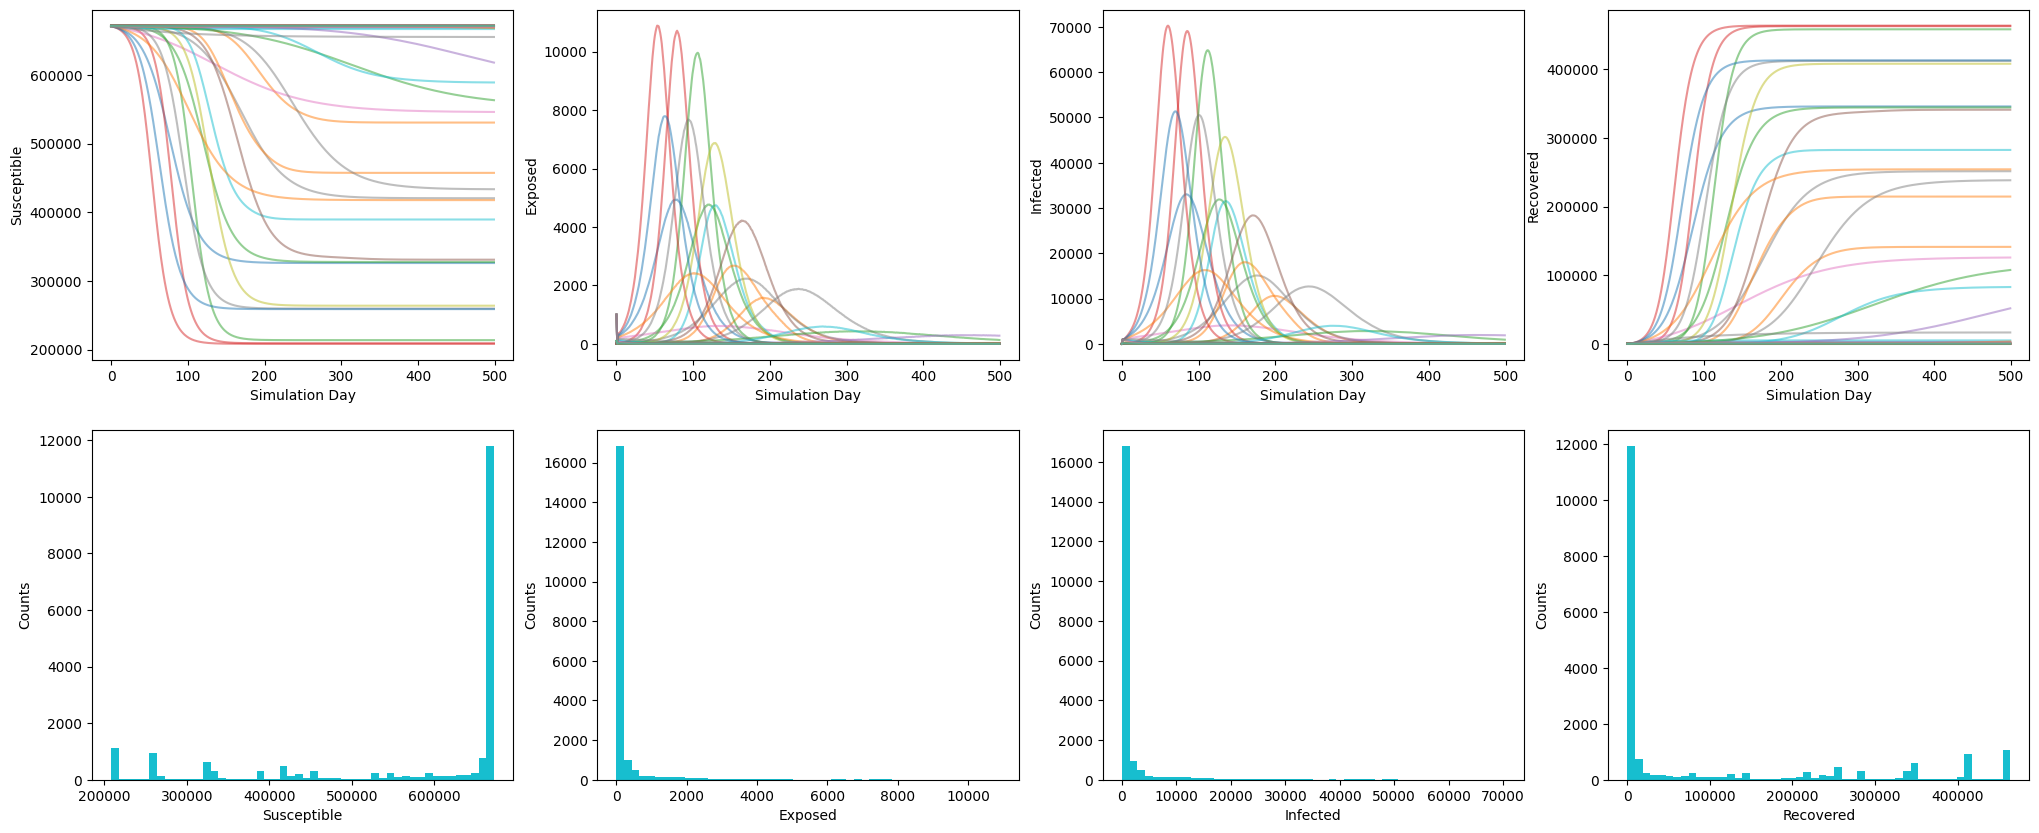

In [7]:
# Collapse data for plotting as a histogram
data_collapsed = data_out.reshape(-1, *data_out.shape[2:])
bins = 50

# Visualize data in feature vs. time space
plt.figure(figsize=(25,10))
for sim_ind in range(0,len(data_out)):
            plt.subplot(2,4,1)
            plt.plot(data_out[sim_ind,:,0].cpu(),alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Susceptible')
            plt.subplot(2,4,2)
            plt.plot(data_out[sim_ind,:,1].cpu(),alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Exposed')
            plt.subplot(2,4,3)
            plt.plot(data_out[sim_ind,:,2].cpu(),alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Infected')
            plt.subplot(2,4,4)
            plt.plot(data_out[sim_ind,:,3].cpu(),alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Recovered')
            plt.subplot(2,4,5)
            plt.hist(data_collapsed[...,0].cpu(), bins = bins)
            plt.xlabel('Susceptible')
            plt.ylabel('Counts')
            plt.subplot(2,4,6)
            plt.hist(data_collapsed[...,1].cpu(), bins = bins)
            plt.xlabel('Exposed')
            plt.ylabel('Counts')
            plt.subplot(2,4,7)
            plt.hist(data_collapsed[...,2].cpu(), bins = bins)
            plt.xlabel('Infected')
            plt.ylabel('Counts')
            plt.subplot(2,4,8)
            plt.hist(data_collapsed[...,3].cpu(), bins = bins)
            plt.xlabel('Recovered')
            plt.ylabel('Counts')


Here we see our first quirk of surrogate modeling with simulation data! Because the dataset evolves dynamically, it tends to cluster around attractors, or equilibrium states. In the case of our epidemic dataset, the zero solution (i.e, an epidemic does not occur) is an equilibrium state, and our data appears is heavily skewed toward the zero solution. The upshot is that we end up with a very "peaky" dataset, in which each peak corresponds to a recurring state of the system, that doesn't lend itself to an obvious normalization scheme. In situations like this, we default to a simple min/max scaling. 

Note that while our normalization scheme is simple, the distribution of our data is still very relevant to the design of our network. Later on in the tutorial, we will address our the "zero-inflation" observed above with a specific architectural choice.

In [4]:
# Normalize per feature
norm_factors = torch.zeros((num_features,2))
for ind_features in range(0,num_features):
    norm_factors[ind_features,0] = torch.min(data_out[:,:,ind_features])
    norm_factors[ind_features,1] = torch.max(data_out[:,:,ind_features])-torch.min(data_out[:,:,ind_features])

for ind_features in range(0,num_features):    
    data_out[:,:,ind_features] = (data_out[:,:,ind_features]-norm_factors[ind_features,0])/float(norm_factors[ind_features,1])


As a final step in our data preparation, we segment the data into a test/train split. Just like a typical machine learning pipeline, this step allows us to monitor for over-fitting during the evaluation step.

In [6]:
# Setup test/train split
test_size = 0.2
data_in_train, data_in_test, data_out_train, data_out_test = train_test_split(
	data_in, data_out, test_size=test_size, random_state=42
	)

# Display shapes of the input and output data
print('Shape of training data:')
print(data_in_train.shape)
print(data_out_train.shape)

print('Shape of test data:')
print(data_in_test.shape)
print(data_out_test.shape)

Shape of training data:
torch.Size([32, 2])
torch.Size([32, 500, 4])
Shape of test data:
torch.Size([8, 2])
torch.Size([8, 500, 4])


## Part 4: Establish an Architecture and Objective

In [ ]:
MENTION CONSTRAINTS! MENTION THAT THESE ARCHITECTURES CAN BE TWEAKED ENDLESSLY TO GURANTEE CERTAIN FEATURES IN THE OUTPUT.

In [8]:
class EPI(torch.nn.Module):

    # Initialization
    def __init__(  
        self,
        basis,
        num_input_parameters: int,
        hidden_channels: int,
        num_total_timesteps: int,
        num_features: int,
        n_epoch: int,
        batch_size: int,
        npop: float,
        learning_rate: float,
        ):

        super().__init__()
        self.hidden_channels = hidden_channels
        self.num_total_timesteps = num_total_timesteps
        self.num_features = num_features
        self.activation = nn.ReLU()
        self.num_input_parameters = num_input_parameters
        self.basis = basis
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.n_epoch = n_epoch
        self.npop = npop

        self.loss = nn.MSELoss()

        self.layer1 = nn.Linear(self.num_input_parameters,self.hidden_channels)
        self.layer2 = nn.Linear(self.hidden_channels,self.hidden_channels)
        self.layer3 = nn.Linear(self.hidden_channels,self.hidden_channels)
        self.layer4 = nn.Linear(self.hidden_channels,self.num_features*self.basis.shape[0])

    # Forward pass function
    def forward(self, xin, x0):

        batch_size = xin.shape[0]

        x = self.layer1(xin)
        x = self.activation(x)
        x = self.layer2(x)
        x = self.activation(x)
        x = self.layer3(x)
        x = self.activation(x)
        x = self.layer4(x)
        A = x.reshape(batch_size,self.num_features,self.basis.shape[0])
        xout = torch.matmul(A,self.basis).permute(0, 2, 1)
        xout = x0 + xout        
        xout = torch.sigmoid(xout)#torch.softmax(xout,dim=-1)#torch.sigmoid(xout)
        return xout

    # Training Loop
    def train(self, data_in, data_out, data_in_test, data_out_test):

        print('Setting up optimizer...')
        optimizer = optim.Adam([
            {'params': self.layer1.parameters()},
            {'params': self.layer2.parameters()},
            {'params': self.layer3.parameters()},
            {'params': self.layer4.parameters()},
            ],lr = self.learning_rate)

        print('Starting training...')
        for it in range(0, self.n_epoch):

            ind_shuffle = torch.randperm(data_in.size()[0])
            data_in = data_in[ind_shuffle]
            data_out = data_out[ind_shuffle]
            loss_track = 0.0

            start_time = time.perf_counter()

            for ind in range(0,data_in.size()[0],self.batch_size):
                loss = 0.0
                optimizer.zero_grad()
                ind_batch = range(ind,ind+self.batch_size)

                if ind+self.batch_size > data_in.size()[0]:
                    ind_batch = range(ind,data_in.size()[0])
                
                data_pred = self(data_in[ind_batch],data_out[ind_batch,0,:].unsqueeze(1))
                loss = self.loss(data_pred,data_out[ind_batch])
                loss.backward()
                optimizer.step()
                loss_track += float(loss.item())
            end_time = time.perf_counter()

            if it == 0 or (it+1)%1000==0:
                print(
                'Epoch: ' + str(it) + '  |  ' + 'Loss: ' + str(loss_track) + '  |  ' + 'Time: ' + str(int(end_time-start_time))
                )
                ind_sample = np.random.randint(low=0, high=len(data_in), size=20)
                sample_in = data_in[ind_sample]#data_in_test
                sample_out = data_out[ind_sample]#data_out_test
                self.eval(sample_in, sample_out, it)

    def eval(self,sample_in,sample_out,it):

        # Evaluate samples
        start_time = time.perf_counter()
        data_pred = self(sample_in,sample_out[:,0,:].unsqueeze(1))

        for ind_features in range(0,num_features):
            data_pred[:,:,ind_features] = float(norm_factors[ind_features,1])*data_pred[:,:,ind_features]+norm_factors[ind_features,0]
            sample_out[:,:,ind_features] = float(norm_factors[ind_features,1])*sample_out[:,:,ind_features]+norm_factors[ind_features,0]
        

        data_pred = torch.exp(data_pred)
        data_pred[...,0] = self.npop-data_pred[...,0]
        sample_out = torch.exp(sample_out)
        sample_out[...,0] = self.npop - sample_out[...,0]
        end_time = time.perf_counter()

        # Collapse results into a global metric
        data_pred = data_pred.cpu().detach().numpy()
        sample_out = sample_out.cpu().detach().numpy()

        # Plot time series prediction (all simulations)
        plt.figure(figsize=(10,20))
        ybounds = [0,1e0]
        for sim_ind in range(0,len(data_pred)):
            plt.subplot(4,2,1)
            plt.plot(data_pred[sim_ind,:,0],alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Susceptible')
            plt.title('Prediction')
            #plt.ylim(ybounds)
            plt.subplot(4,2,2)
            plt.plot(sample_out[sim_ind,:,0],alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Susceptible')
            plt.title('Truth')
            #plt.ylim(ybounds)
            plt.subplot(4,2,3)
            plt.plot(data_pred[sim_ind,:,1],alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Exposed')
            plt.title('Prediction')
            #plt.ylim(ybounds)
            plt.subplot(4,2,4)
            plt.plot(sample_out[sim_ind,:,1],alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Susceptible')
            plt.title('Truth')
            #plt.ylim(ybounds)
            plt.subplot(4,2,5)
            plt.plot(data_pred[sim_ind,:,2],alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Infected')
            plt.title('Prediction')
            #plt.ylim(ybounds)
            plt.subplot(4,2,6)
            plt.plot(sample_out[sim_ind,:,2],alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Infected')
            plt.title('Truth')
            #plt.ylim(ybounds)
            plt.subplot(4,2,7)
            plt.plot(data_pred[sim_ind,:,3],alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Recovered')
            plt.title('Prediction')
            #plt.ylim(ybounds)
            plt.subplot(4,2,8)
            plt.plot(sample_out[sim_ind,:,3],alpha=0.5)
            plt.xlabel('Simulation Day')
            plt.ylabel('Recovered')
            plt.title('Truth')
            #plt.ylim(ybounds)
        plt.savefig("figures/susceptible_" + str(it) +  ".png")
        print('figure saved for epoch' + str(it))                

## Part 5: Train the Model

In [13]:
# Extract tailored basis from PCA
numPCA = int(5)
pca = PCA(n_components=numPCA, svd_solver='auto')
X = np.permute_dims(data_out.cpu(), axes=(0,2,1))
X = X.reshape(-1, *X.shape[2:])
pca.fit(X)
basis = pca.components_[0:numPCA]
basis = torch.tensor(basis,dtype=torch.float32)
basis = basis.to(device)

# Initialize model architecture
print('Initializing model...')
epi = EPI(
	hidden_channels=32,
	n_epoch= 5000,
	batch_size=16,
	learning_rate = 1e-3,
	num_total_timesteps=500,
	num_features = 4,
    num_input_parameters = 2,
	basis = basis,
    npop = npop
	)
epi = epi.to(device)

Initializing model...


Setting up optimizer...
Starting training...
Epoch: 0  |  Loss: 0.38854749500751495  |  Time: 0
figure saved for epoch0
Epoch: 999  |  Loss: 0.02201396133750677  |  Time: 0
figure saved for epoch999
Epoch: 1999  |  Loss: 0.005833513336256146  |  Time: 0
figure saved for epoch1999
Epoch: 2999  |  Loss: 0.004617270431481302  |  Time: 0
figure saved for epoch2999
Epoch: 3999  |  Loss: 0.001498964091297239  |  Time: 0
figure saved for epoch3999
Epoch: 4999  |  Loss: 0.0011571747600100935  |  Time: 0
figure saved for epoch4999


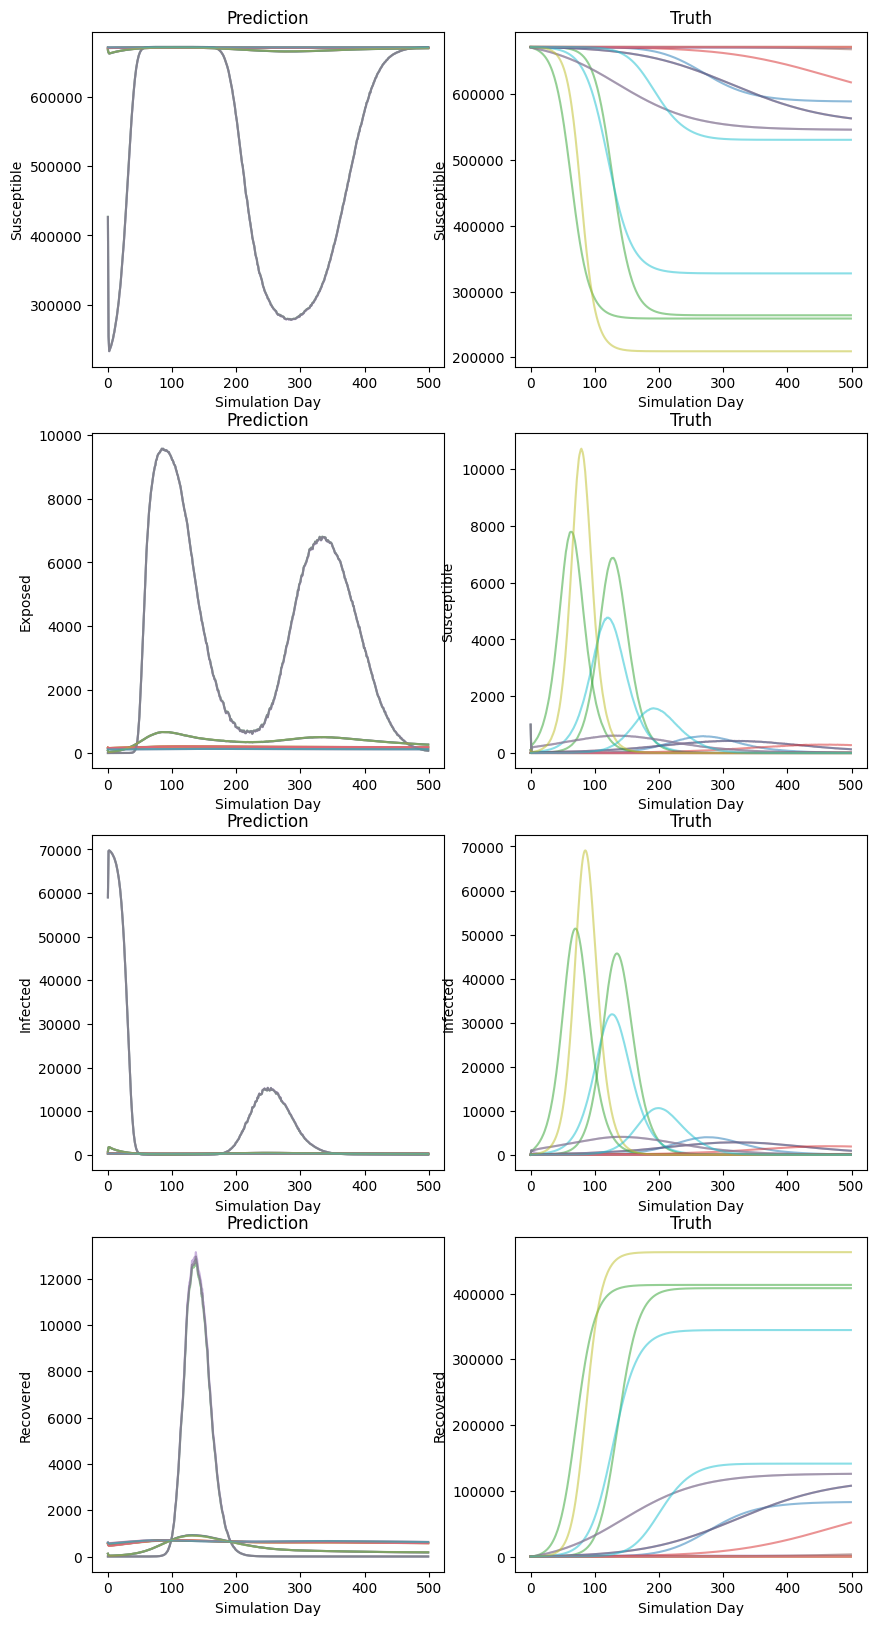

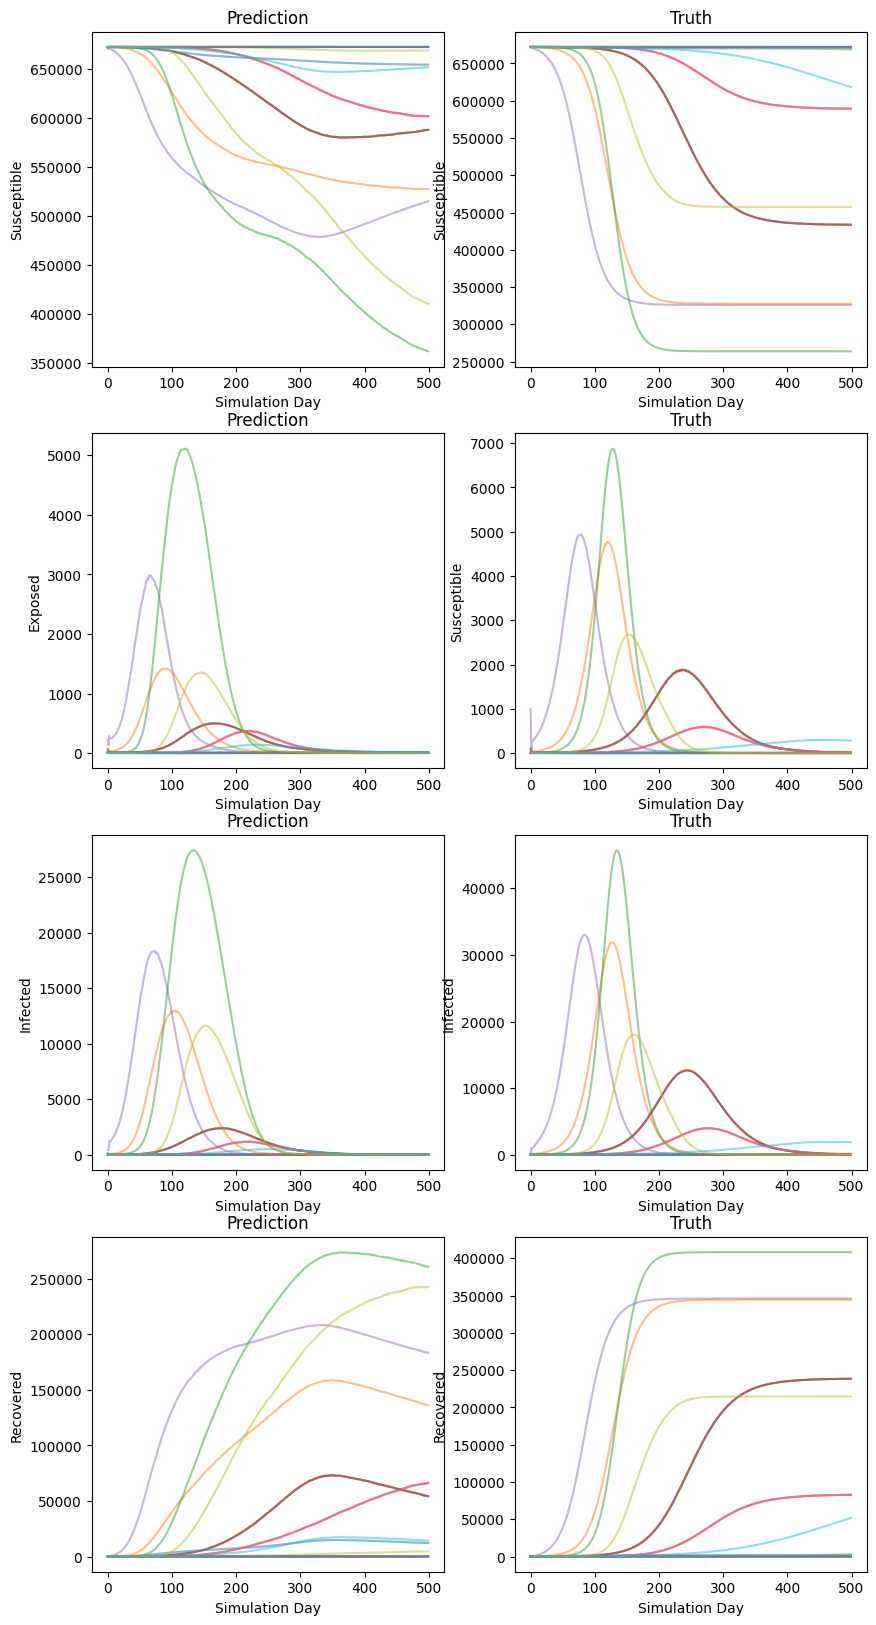

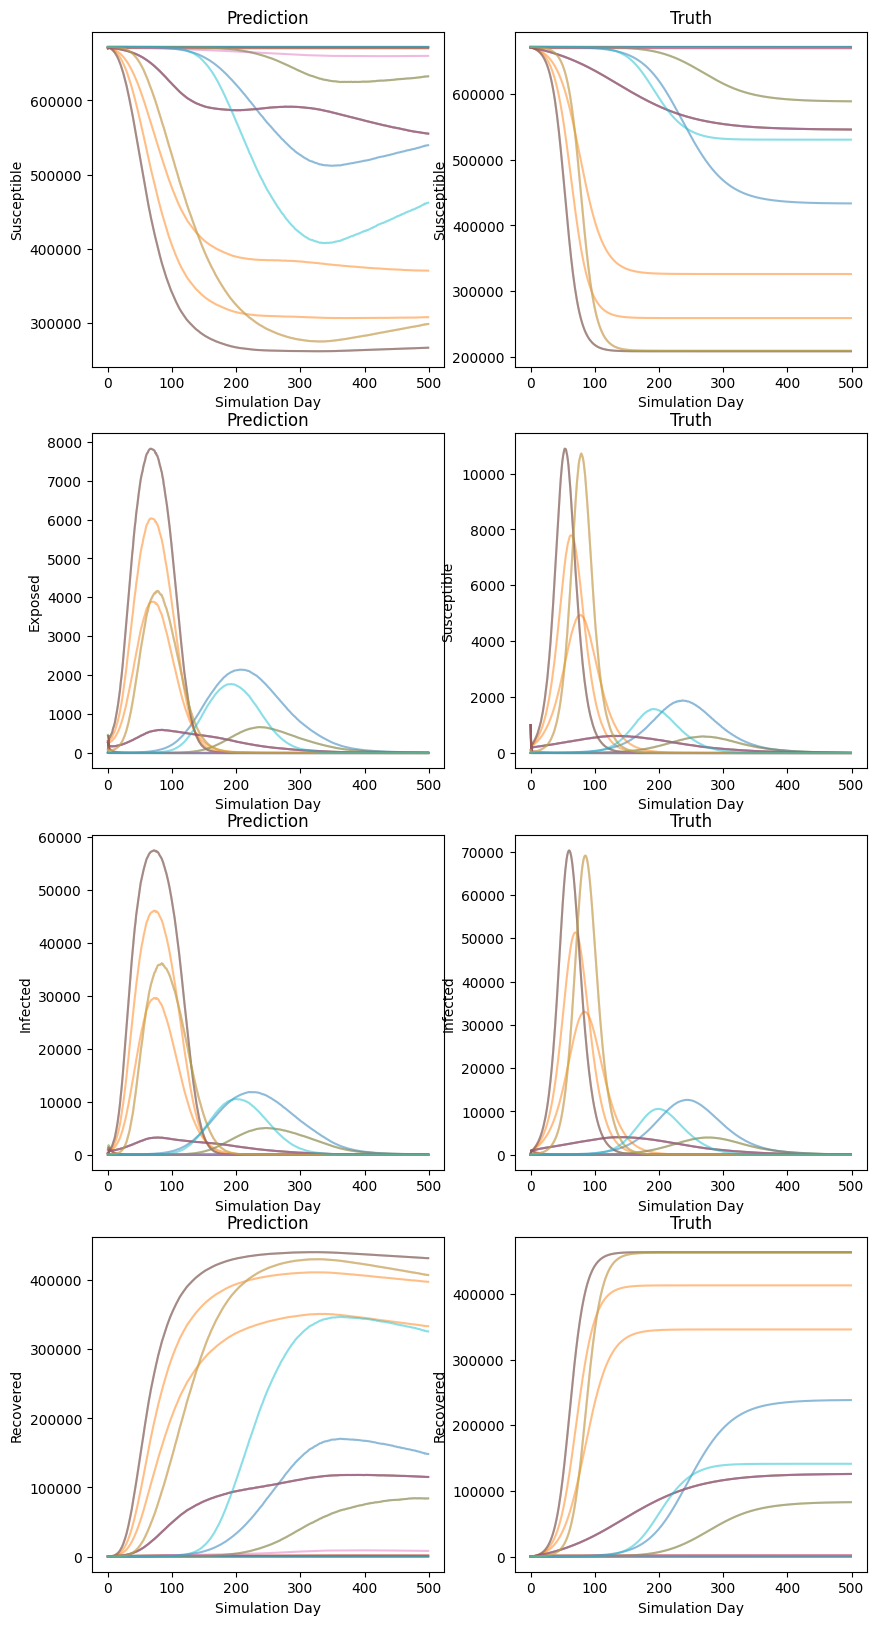

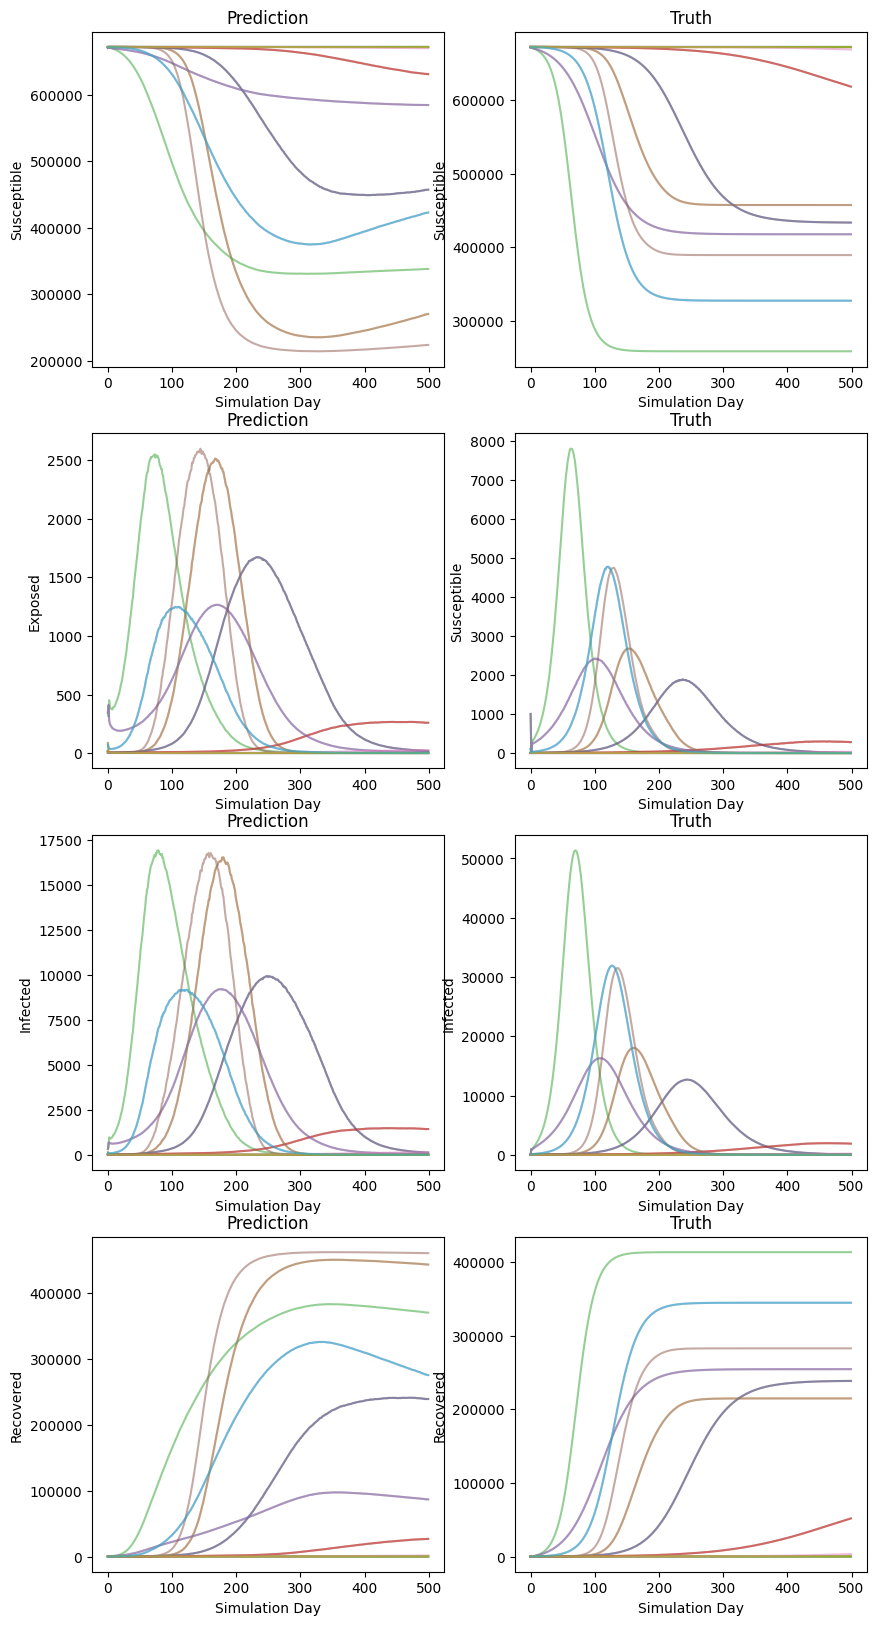

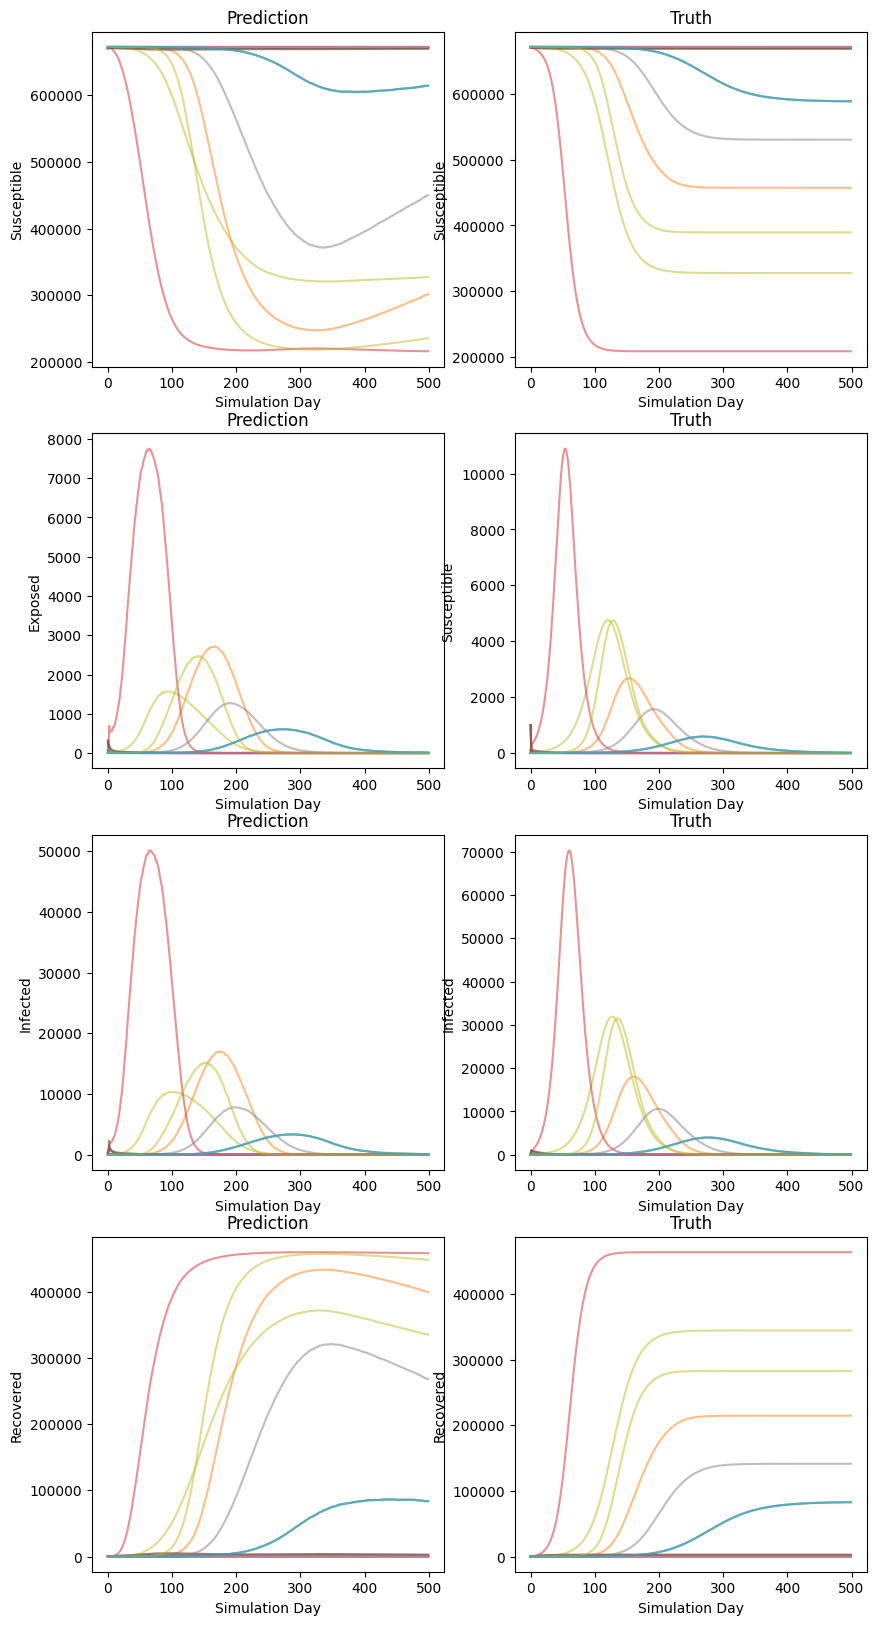

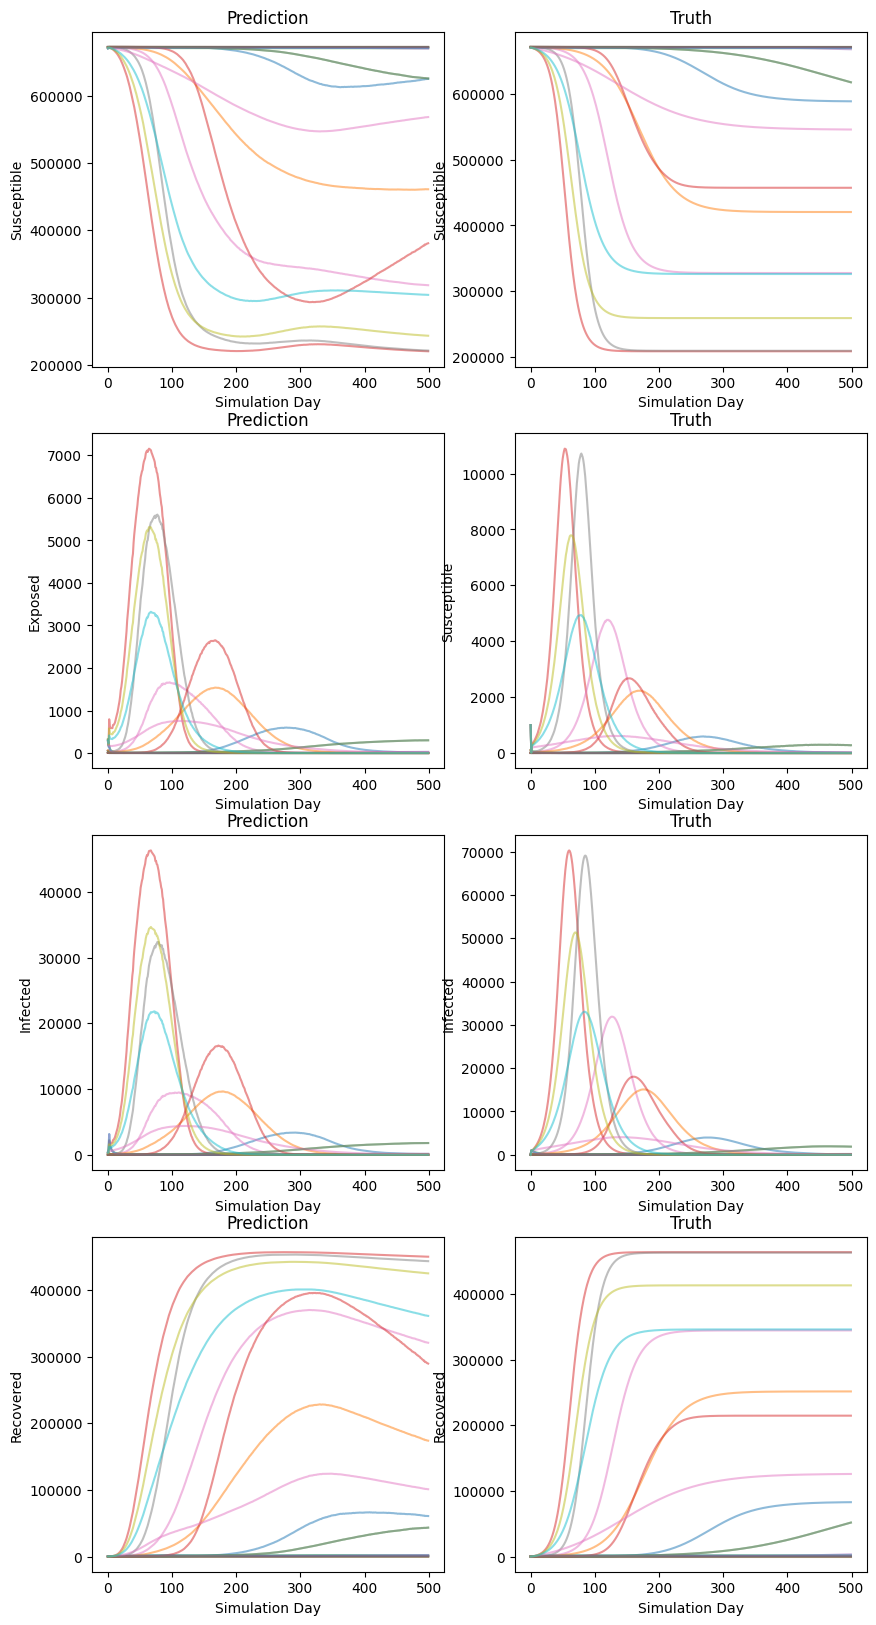

In [14]:
# Train model
epi.train(data_in_train,data_out_train,data_in_test,data_out_test)